Loading German Credit dataset ...
Dataset shape: (1000, 21)

Target classes: ['good', 'bad']
Categories (2, object): ['bad', 'good']

Missing values per column:
 0 total missing cells

Categorical columns (13): ['checking_status', 'credit_history', 'purpose', 'savings_status', 'employment', 'personal_status', 'other_parties', 'property_magnitude', 'other_payment_plans', 'housing', 'job', 'own_telephone', 'foreign_worker']
Numeric columns (7): ['duration', 'credit_amount', 'installment_commitment', 'residence_since', 'age', 'existing_credits', 'num_dependents']

Preprocessed data sample:

Class distribution (0=Good, 1=Bad):
target
0    700
1    300
Name: count, dtype: int64
Bad-credit rate: 30.0%  <-- this is an imbalanced dataset

Training samples: 800 | Testing samples: 200
Train class balance:
 target
0    0.7
1    0.3
Name: proportion, dtype: float64
Test class balance:
 target
0    0.7
1    0.3
Name: proportion, dtype: float64
Model trained successfully.

Top 10 most influential fe

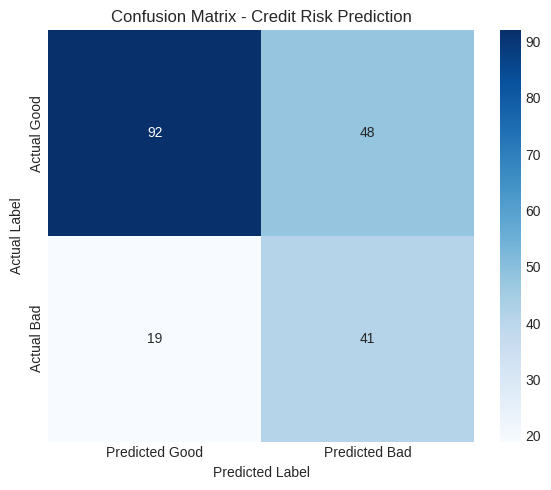

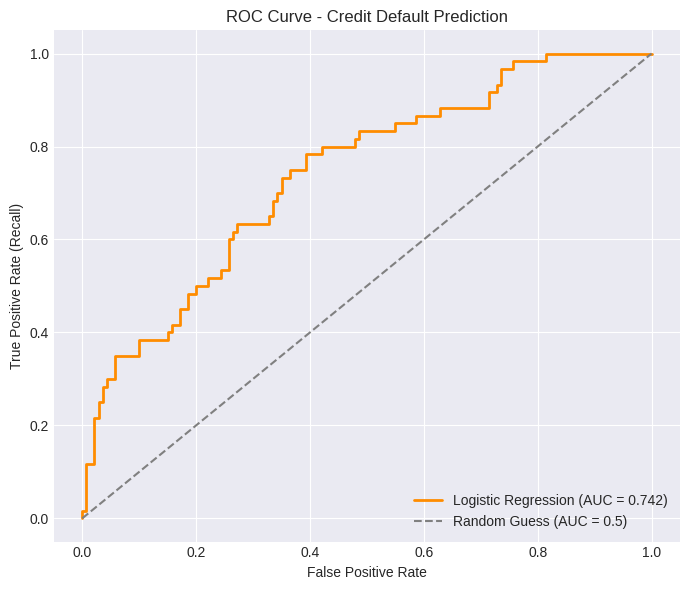

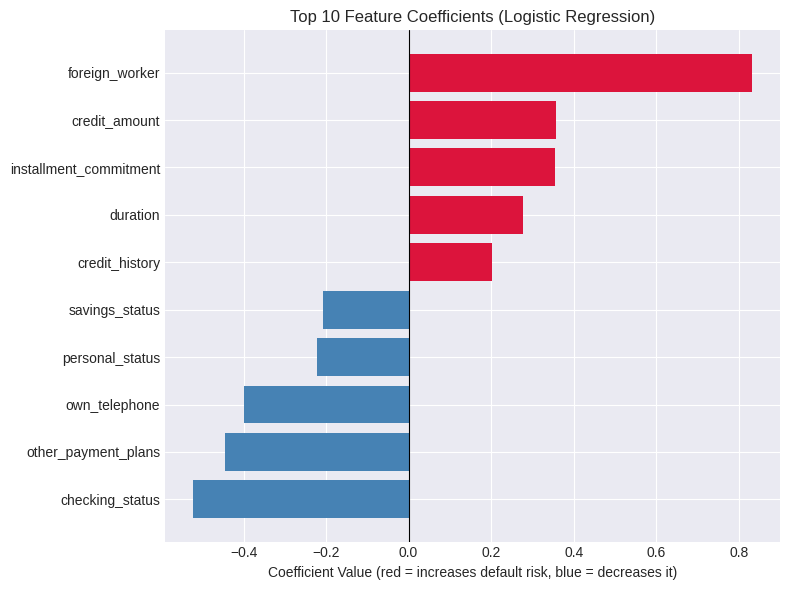


===== SUMMARY =====
Model: Logistic Regression (L2 / Ridge penalty, class_weight='balanced')
ROC-AUC: 0.7415 | F1-Score: 0.5503 | Recall (catching bad credit): 0.6833

Interview tip: In credit risk, RECALL on the 'bad' class often matters more
than raw accuracy -- missing a genuine defaulter (false negative) is usually
more costly to a bank than flagging a good customer for extra review (false positive).


In [2]:
"""
=====================================================================
 CREDIT RISK AND DEFAULT PREDICTION
=====================================================================
A beginner-friendly, classic Machine Learning classification project
that predicts whether a loan applicant is a GOOD credit risk or a
BAD credit risk (i.e. likely to default), using the well-known
German Credit dataset.

Model      : Logistic Regression with L2 (Ridge) regularization
Libraries  : pandas, numpy, scikit-learn, matplotlib, seaborn

Dataset    : "credit-g" (German Credit Data), fetched directly via
             scikit-learn's fetch_openml -- no manual download needed.
             1000 rows, mix of numeric + categorical features,
             target = 'good' or 'bad' credit risk (imbalanced ~70/30).

Each numbered section (# %%) is written so you can copy it into its
own Google Colab / Jupyter cell.
=====================================================================
"""

# %% ------------------------------------------------------------------
# STEP 0: IMPORT LIBRARIES
# -----------------------------------------------------------------
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.datasets import fetch_openml
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    roc_auc_score, roc_curve, confusion_matrix, classification_report
)

plt.style.use("seaborn-v0_8-darkgrid")
RANDOM_STATE = 42


# %% ------------------------------------------------------------------
# STEP 1: DATA LOADING & PREPROCESSING
# -----------------------------------------------------------------
# fetch_openml downloads the dataset directly from OpenML's public
# repository -- no manual file handling needed. as_frame=True gives
# us a clean pandas DataFrame right away.
print("Loading German Credit dataset ...")
credit_data = fetch_openml(name="credit-g", version=1, as_frame=True)

df = credit_data.frame.copy()
print("Dataset shape:", df.shape)
print("\nTarget classes:", df["class"].unique())
df.head()

# --- Handle Missing Values -------------------------------------------
# Check for missing values across all columns.
print("\nMissing values per column:\n", df.isnull().sum().sum(), "total missing cells")

# This dataset is clean, but as good practice we still handle NaNs:
# - Numeric columns: fill with median (robust to outliers)
# - Categorical columns: fill with mode (most frequent category)
for col in df.columns:
    if df[col].isnull().sum() > 0:
        if df[col].dtype in [np.float64, np.int64]:
            df[col].fillna(df[col].median(), inplace=True)
        else:
            df[col].fillna(df[col].mode()[0], inplace=True)

# --- Encode the Target Variable ----------------------------------------
# 'good' -> 0 (no default risk), 'bad' -> 1 (default risk)
# We map explicitly (rather than blind LabelEncoder) so we KNOW which
# class is "1" -- important since it drives Precision/Recall interpretation.
#
# NOTE: fetch_openml returns 'class' as a pandas Categorical dtype.
# Mapping a Categorical column can leave the result as dtype 'category'
# instead of a plain integer, which later breaks select_dtypes(np.number).
# Converting to string first, then casting the mapped result to int,
# guarantees we get a clean numeric column.
df["target"] = df["class"].astype(str).map({"good": 0, "bad": 1}).astype(int)
df.drop(columns=["class"], inplace=True)

# Sanity check: make sure no rows failed to map (would show up as NaN)
assert df["target"].isnull().sum() == 0, "Some 'class' values didn't map to 0/1 -- check for typos/whitespace."

# --- Encode Categorical Features ----------------------------------------
# Identify categorical (object/category) columns vs numeric columns.
categorical_cols = df.select_dtypes(include=["object", "category"]).columns.tolist()
numeric_cols = df.select_dtypes(include=[np.number]).columns.tolist()

# Defensive check: confirm 'target' ended up numeric before removing it.
# (Prints a clear diagnostic instead of crashing if a dtype issue slips through.)
if "target" in numeric_cols:
    numeric_cols.remove("target")
else:
    raise TypeError(
        f"'target' column has dtype {df['target'].dtype}, expected a numeric dtype. "
        "Check the target-encoding step above."
    )

print(f"\nCategorical columns ({len(categorical_cols)}): {categorical_cols}")
print(f"Numeric columns ({len(numeric_cols)}): {numeric_cols}")

# Label Encoding converts each category to an integer code.
# (One-Hot Encoding is an alternative, but Label Encoding keeps the
# feature count small and is simple to explain in interviews.)
label_encoders = {}
for col in categorical_cols:
    le = LabelEncoder()
    df[col] = le.fit_transform(df[col])
    label_encoders[col] = le  # saved in case we need to decode later

# --- Scale Numerical Features --------------------------------------------
# Logistic Regression is sensitive to feature scale (it uses gradient
# descent / regularization on coefficients), so we standardize numeric
# columns to mean=0, std=1.
scaler = StandardScaler()
df[numeric_cols] = scaler.fit_transform(df[numeric_cols])

print("\nPreprocessed data sample:")
df.head()


# %% ------------------------------------------------------------------
# STEP 2: HANDLING IMBALANCE & TRAIN-TEST SPLIT
# -----------------------------------------------------------------
X = df.drop(columns=["target"])
y = df["target"]

print("\nClass distribution (0=Good, 1=Bad):")
print(y.value_counts())
print(f"Bad-credit rate: {y.mean()*100:.1f}%  <-- this is an imbalanced dataset")

# --- Train-Test Split ----------------------------------------------------
# stratify=y ensures both train and test sets preserve the same
# good/bad class ratio as the full dataset -- important for imbalanced data.
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=RANDOM_STATE, stratify=y
)

print(f"\nTraining samples: {len(X_train)} | Testing samples: {len(X_test)}")
print("Train class balance:\n", y_train.value_counts(normalize=True))
print("Test class balance:\n", y_test.value_counts(normalize=True))


# %% ------------------------------------------------------------------
# STEP 3: MODEL TRAINING - LOGISTIC REGRESSION (L2 / RIDGE)
# -----------------------------------------------------------------
# penalty='l2' (Ridge) shrinks coefficients to reduce overfitting,
# without forcing any of them to exactly zero (unlike L1/Lasso, which
# can perform feature selection by zeroing out weak features).
#
# class_weight='balanced' automatically re-weights classes inversely
# proportional to their frequency -- this helps the model pay proper
# attention to the minority ("bad" credit) class instead of just
# predicting "good" for everyone to maximize raw accuracy.
model = LogisticRegression(
    penalty="l2",
    C=1.0,                     # inverse of regularization strength (lower C = stronger regularization)
    class_weight="balanced",   # helps handle class imbalance
    max_iter=1000,
    random_state=RANDOM_STATE
)
model.fit(X_train, y_train)

print("Model trained successfully.")

# --- Inspect Feature Coefficients -----------------------------------------
# In Logistic Regression, each coefficient shows how strongly (and in
# which direction) a feature pushes the prediction toward "bad" credit.
# Positive coefficient -> increases risk of default.
# Negative coefficient -> decreases risk of default.
coef_df = pd.DataFrame({
    "Feature": X.columns,
    "Coefficient": model.coef_[0]
}).sort_values(by="Coefficient", key=abs, ascending=False)

print("\nTop 10 most influential features:")
print(coef_df.head(10))


# %% ------------------------------------------------------------------
# STEP 4: MODEL EVALUATION
# -----------------------------------------------------------------
# --- Predictions -----------------------------------------------------------
y_pred = model.predict(X_test)                     # hard class predictions (0/1)
y_pred_proba = model.predict_proba(X_test)[:, 1]   # predicted probability of "bad" credit

# --- Core Classification Metrics --------------------------------------------
accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)
roc_auc = roc_auc_score(y_test, y_pred_proba)

print("\n===== MODEL PERFORMANCE =====")
print(f"Accuracy : {accuracy:.4f}")
print(f"Precision: {precision:.4f}  (of predicted 'bad' credit, how many were truly bad)")
print(f"Recall   : {recall:.4f}  (of all truly 'bad' credit cases, how many we caught)")
print(f"F1-Score : {f1:.4f}  (harmonic mean of precision & recall)")
print(f"ROC-AUC  : {roc_auc:.4f}  (ability to rank 'bad' higher than 'good' overall)")

print("\nFull classification report:")
print(classification_report(y_test, y_pred, target_names=["Good Credit", "Bad Credit"]))


# %% ------------------------------------------------------------------
# STEP 5: VISUALIZATION
# -----------------------------------------------------------------
# --- Plot 1: Confusion Matrix --------------------------------------------
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(6, 5))
sns.heatmap(
    cm, annot=True, fmt="d", cmap="Blues",
    xticklabels=["Predicted Good", "Predicted Bad"],
    yticklabels=["Actual Good", "Actual Bad"]
)
plt.title("Confusion Matrix - Credit Risk Prediction")
plt.ylabel("Actual Label")
plt.xlabel("Predicted Label")
plt.tight_layout()
plt.savefig("confusion_matrix.png", dpi=150)
plt.show()

# --- Plot 2: ROC Curve ----------------------------------------------------
fpr, tpr, thresholds = roc_curve(y_test, y_pred_proba)

plt.figure(figsize=(7, 6))
plt.plot(fpr, tpr, color="darkorange", linewidth=2, label=f"Logistic Regression (AUC = {roc_auc:.3f})")
plt.plot([0, 1], [0, 1], color="gray", linestyle="--", label="Random Guess (AUC = 0.5)")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate (Recall)")
plt.title("ROC Curve - Credit Default Prediction")
plt.legend(loc="lower right")
plt.tight_layout()
plt.savefig("roc_curve.png", dpi=150)
plt.show()

# --- Plot 3: Top Feature Coefficients --------------------------------------
top_features = coef_df.head(10).sort_values(by="Coefficient")

plt.figure(figsize=(8, 6))
colors = ["crimson" if c > 0 else "steelblue" for c in top_features["Coefficient"]]
plt.barh(top_features["Feature"], top_features["Coefficient"], color=colors)
plt.axvline(x=0, color="black", linewidth=0.8)
plt.title("Top 10 Feature Coefficients (Logistic Regression)")
plt.xlabel("Coefficient Value (red = increases default risk, blue = decreases it)")
plt.tight_layout()
plt.savefig("feature_coefficients.png", dpi=150)
plt.show()

# --- Quick Summary -------------------------------------------------------
print("\n===== SUMMARY =====")
print(f"Model: Logistic Regression (L2 / Ridge penalty, class_weight='balanced')")
print(f"ROC-AUC: {roc_auc:.4f} | F1-Score: {f1:.4f} | Recall (catching bad credit): {recall:.4f}")
print("\nInterview tip: In credit risk, RECALL on the 'bad' class often matters more")
print("than raw accuracy -- missing a genuine defaulter (false negative) is usually")
print("more costly to a bank than flagging a good customer for extra review (false positive).")